In [16]:
import pandas as pd
import seaborn as sns
import numpy as np
import os

In [17]:
def load_bulk_data(
    path_to_boot="/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/bulkEGADPipeline/results/allbulk_reallabels"
) -> pd.DataFrame:
    lo_boots = np.sort(np.array(os.listdir(path_to_boot)).astype(int))
    lo_boot_paths = [f'{path_to_boot}/{boot}' for boot in lo_boots]
    lo_egads = os.listdir(f"{path_to_boot}/1/EGAD")

    lo_egad_paths = [f'{boot_path}/EGAD/{egad}' for boot_path in lo_boot_paths for egad in lo_egads]
    lo_boots_for_df = [path.split("/")[-3] for path in lo_egad_paths]

    lo_dfs = []
    for i, path in enumerate(lo_egad_paths):
        df = pd.read_csv(path, index_col=0)
        df['boot'] = lo_boots_for_df[i]
        lo_dfs.append(df)

    all_dfs = pd.concat(lo_dfs).reset_index()
    bulk_mean = all_dfs.groupby('index')['auc'].mean()
    return bulk_mean.to_frame()

bulk = load_bulk_data()
bulk.head()

,auc
index,
GO:0000045,0.620141
GO:0000070,0.800842
GO:0000077,0.688138
GO:0000079,0.625484
GO:0000082,0.650001


In [18]:
def load_ct_data(
    path_to_boot="/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/ctProfilePipeline/data/allsc_reallabels"
) -> pd.DataFrame:
    lo_boots = np.sort(np.array(os.listdir(path_to_boot)).astype(int))
    lo_boot_paths = [f'{path_to_boot}/{boot}' for boot in lo_boots]
    lo_egads = os.listdir(f"{path_to_boot}/1/EGAD")

    lo_egad_paths = [f'{boot_path}/EGAD/{egad}' for boot_path in lo_boot_paths for egad in lo_egads]
    lo_boots_for_df = [path.split("/")[-3] for path in lo_egad_paths]

    lo_dfs = []
    for i, path in enumerate(lo_egad_paths):
        df = pd.read_csv(path, index_col=0)
        df['boot'] = lo_boots_for_df[i]
        lo_dfs.append(df)

    all_dfs = pd.concat(lo_dfs).reset_index()
    ct_mean = all_dfs.groupby('index')['auc'].mean().reset_index()
    return ct_mean

cts = load_ct_data()
cts.head()

,index,auc
0,GO:0000045,0.531789
1,GO:0000070,0.766095
2,GO:0000077,0.608656
3,GO:0000079,0.636014
4,GO:0000082,0.545763


In [19]:
# def load_expansion_data(path_to_boot = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/expansionSimulation/data/bootmarch")->pd.DataFrame:

#     lo_boots = np.array(os.listdir(path_to_boot))
#     lo_boots = np.sort(lo_boots.astype(int))
#     lo_boots = lo_boots[0:-2]
#     lo_boot_paths = [f'{path_to_boot}/{boot}' for boot in lo_boots]
#     lo_egads = os.listdir("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/expansionSimulation/data/bootmarch/1/EGAD")

#     lo_egads_paths = [f'{boot_path}/EGAD/{egad}' for boot_path in lo_boot_paths for egad in lo_egads]
#     lo_dfs = [pd.read_csv(path) for path in lo_egads_paths]
#     # Get metadata
#     lo_ncts_for_df = [string.split("/")[-1].split("_")[0] for string in lo_egads_paths]
#     lo_boots_for_df = [string.split("/")[-3] for string in lo_egads_paths]
    
#     # Add metadata to each df
#     def add_metadata(lo_dfs, lo_ncts_for_df, lo_boots_for_df) -> list:
#         lo_dfs_meta = []
#         for i, df in enumerate(lo_dfs):
#             nct = lo_ncts_for_df[i]
#             boot = lo_boots_for_df[i]
            
#             # print(nct)
#             # print(boot)
#             df['nct'] = nct
#             df['boot'] = boot
            
#             lo_dfs_meta.append(df)
#         return lo_dfs_meta
#     lo_dfs_meta = add_metadata(lo_dfs=lo_dfs,
#                                lo_ncts_for_df=lo_ncts_for_df,
#                                lo_boots_for_df=lo_boots_for_df)
    
#     def concat_dfs(lo_dfs_meta) -> pd.DataFrame:
#         all_dfs_concat = pd.concat(lo_dfs_meta, axis = 0)
#         all_dfs_concat = all_dfs_concat.reset_index()
#         graph_dfs = all_dfs_concat.groupby(['nct', 'index'])['auc'].mean().reset_index()
#         graph_dfs['nct'] = pd.to_numeric(graph_dfs['nct'])
#         graph_dfs.sort_values('nct', ascending=True).nct.unique()
#         return graph_dfs
    
#     graph_dfs = concat_dfs(lo_dfs_meta=lo_dfs_meta)
    
#     def load_metadata(path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessGO_pipe/data/2024_march/data/GOCurations.tsv")->pd.DataFrame:
#         GO_curations = pd.read_csv(path, sep = "\t").loc[:,['id', 'CTAffiliated']]
#         return GO_curations
    
#     GO_curations = load_metadata()
    
#     # Combine metadata with performance
#     graph_with_meta = graph_dfs.merge(GO_curations, left_on='index', right_on = 'id')
        
#     return graph_with_meta
        
# graph_dfs_mean_cta = load_expansion_data()


In [20]:
        
# max_ct = graph_dfs_mean_cta[graph_dfs_mean_cta.loc[:,'nct']==85]
# max_ct

In [21]:
merged = pd.merge(bulk, cts, left_index=True, right_on='index', suffixes=['_bulk','_ct'])
merged.head()

,auc_bulk,index,auc_ct
0,0.620141,GO:0000045,0.531789
1,0.800842,GO:0000070,0.766095
2,0.688138,GO:0000077,0.608656
3,0.625484,GO:0000079,0.636014
4,0.650001,GO:0000082,0.545763


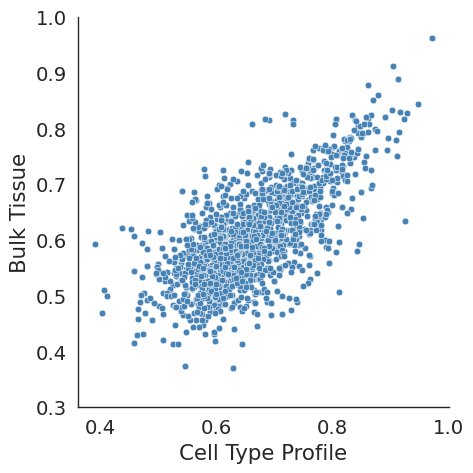

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import os
os.makedirs("results", exist_ok=True)
# Assuming `merged` is your DataFrame
# Calculate Spearman correlation
corr, p_value = spearmanr(merged['auc_bulk'], merged['auc_ct'])

sns.set(style="white")  # Cleaner look with grid
sns.set_context("paper", font_scale=1.6)  # Scale for print or slides
plt.figure(figsize=(5, 5))  # Adjust size as needed

# Create scatter plot
ax = sns.scatterplot(data=merged, x='auc_bulk', y='auc_ct', color = 'steelblue')

# Set axis labels
ax.set_xlabel("Cell Type Profile", )
ax.set_ylabel("Bulk Tissue",)

ax.set_ylim([0.3,1])
ax.set_ylim([0.3,1])


# Optional: remove top and right spines for cleaner appearance
sns.despine()
# Tweak layout
plt.tight_layout()
plt.savefig("results/ct_corr_bulk.svg", dpi=300, bbox_inches="tight")

plt.show()


In [23]:
from scipy.stats import spearmanr

# Calculate Spearman correlation
rho, pval = spearmanr(merged['auc_bulk'], merged['auc_ct'])

print(f"Spearman's rho: {rho:.4f}")
print(f"P-value: {pval:.4e}")

Spearman's rho: 0.6716
P-value: 8.4136e-184
